# 06 调参、XGBoost 基线、SHAP 解释、风险分级

对应报告第五节（模型优化与解释）和第六节（风险评估应用），另外做两件事：
1. 加一个 XGBoost 作为额外基线（Kaggle 社区的经验是它在这份数据上很强）。
2. 05 的结论"SVM 和 MLP 组合没用"是在 SVM **没调参**时得出的。这里给 SVM 调完参，再检验一次。

数据切分和 05 完全一样：训练集里 80% 用来训练，20% 当验证集。所有调参、挑阈值、挑权重都只看验证集，测试集只在最后打一次分。

## 0. 准备

In [1]:
import glob
import os
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

if os.path.exists('/content'):
    os.system('apt-get -qq install -y fonts-noto-cjk > /dev/null')
    font_path = glob.glob('/usr/share/fonts/**/NotoSansCJK*-Regular.ttc', recursive=True)[0]
    fm.fontManager.addfont(font_path)
    plt.rcParams['font.family'] = fm.FontProperties(fname=font_path).get_name()
else:
    plt.rcParams['font.family'] = ['PingFang SC', 'Heiti SC', 'Arial Unicode MS', 'sans-serif']
plt.rcParams['axes.unicode_minus'] = False

In [2]:
try:
    import xgboost
    import shap
except ImportError:
    %pip -q install xgboost shap

In [3]:
import time
import itertools
import warnings
import numpy as np
import pandas as pd
from sklearn.exceptions import ConvergenceWarning
from sklearn.model_selection import train_test_split
from sklearn.metrics import average_precision_score, precision_recall_curve
warnings.filterwarnings('ignore', category=ConvergenceWarning)

try:
    from google.colab import drive
    drive.mount('/content/drive')
    DATA_DIR = '/content/drive/MyDrive/data-mining'
except ImportError:
    DATA_DIR = os.environ.get('CCFD_DATA_DIR', 'data')

train_df = pd.read_csv(f'{DATA_DIR}/train_scaled.csv')
test_df = pd.read_csv(f'{DATA_DIR}/test_scaled.csv')
test_amount = pd.read_csv(f'{DATA_DIR}/test_amount_raw.csv')['Amount'].values
feature_cols = [c for c in train_df.columns if c != 'Class']
X_test, y_test = test_df[feature_cols].values, test_df['Class'].values

row_id = pd.util.hash_pandas_object(train_df, index=False).values
uniq = pd.DataFrame({'row_id': row_id, 'Class': train_df['Class'].values}).drop_duplicates('row_id')
fit_ids, _ = train_test_split(uniq['row_id'], test_size=0.2, stratify=uniq['Class'], random_state=42)
is_fit = np.isin(row_id, fit_ids.values)
X_fit, y_fit = train_df.loc[is_fit, feature_cols].values, train_df.loc[is_fit, 'Class'].values
X_val, y_val = train_df.loc[~is_fit, feature_cols].values, train_df.loc[~is_fit, 'Class'].values

rng = np.random.default_rng(42)
svm_rows = np.concatenate([np.flatnonzero(y_fit == 1),
                           rng.choice(np.flatnonzero(y_fit == 0), 20000, replace=False)])
print(f'拟合用 {len(y_fit)} 行，验证集 {len(y_val)} 行，测试集 {len(y_test)} 行')

拟合用 159509 行，验证集 39882 行，测试集 85416 行


## 1. 调参：SVM（网格搜索）

SVM 有两个关键参数：
- `C`：对"分错"的惩罚有多重。越大越努力把训练样本全分对，越容易过拟合。
- `gamma`：RBF 核的"影响范围"。越大，每个样本只影响身边很小的一块，分界线越弯越碎。

把 4 × 3 = 12 种组合都试一遍，每种在验证集上算 AUPRC，选最高的。大约要 1~3 分钟。

In [4]:
from sklearn.svm import SVC

svm_grid, svm_models = [], {}
for C, gamma in itertools.product([0.1, 1, 10, 100], ['scale', 0.01, 0.1]):
    start = time.time()
    m = SVC(kernel='rbf', C=C, gamma=gamma, class_weight='balanced', random_state=42)
    m.fit(X_fit[svm_rows], y_fit[svm_rows])
    ap = average_precision_score(y_val, m.decision_function(X_val))
    svm_models[(C, gamma)] = m
    svm_grid.append({'C': C, 'gamma': gamma, '验证集 AUPRC': ap, '耗时(秒)': time.time() - start})

svm_grid = pd.DataFrame(svm_grid).sort_values('验证集 AUPRC', ascending=False)
best_C, best_gamma = svm_grid.iloc[0]['C'], svm_grid.iloc[0]['gamma']
svm_tuned = svm_models[(best_C, best_gamma)]
default_ap = average_precision_score(y_val, svm_models[(1, 'scale')].decision_function(X_val))
print(f'最优：C={best_C}，gamma={best_gamma}；默认参数（C=1, gamma=scale）的验证集 AUPRC = {default_ap:.4f}')
svm_grid.round(4)

最优：C=100.0，gamma=scale；默认参数（C=1, gamma=scale）的验证集 AUPRC = 0.3866


,C,gamma,验证集 AUPRC,耗时(秒)
9,100.0,scale,0.6270,1.5632
10,100.0,0.01,0.6107,1.2354
6,10.0,scale,0.5800,2.1679
1,0.1,0.01,0.5376,8.6680
7,10.0,0.01,0.4883,2.5480
0,0.1,scale,0.4571,8.2267
3,1.0,scale,0.3866,4.5842
4,1.0,0.01,0.3586,4.9300
8,10.0,0.1,0.2964,6.9662
5,1.0,0.1,0.2592,8.3682


## 2. 调参：随机森林（随机搜索）

随机森林参数多，组合太多试不完，所以随机抽 8 组来试：
- `n_estimators`：树的数量；`max_depth`：每棵树最多长几层；`min_samples_leaf`：叶子上最少几个样本（越大越不容易记住个别样本）；`max_features`：每次分叉时看多少个特征；`class_weight`：要不要加类别权重。

大约要 3~6 分钟。

In [5]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import ParameterSampler

space = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20],
    'min_samples_leaf': [1, 3, 5],
    'max_features': ['sqrt', 0.5],
    'class_weight': [None, 'balanced'],
}
candidates = [{'n_estimators': 100, 'max_depth': None, 'min_samples_leaf': 1,
               'max_features': 'sqrt', 'class_weight': 'balanced'}]
candidates += list(ParameterSampler(space, n_iter=8, random_state=42))

rf_grid, rf_models = [], []
for i, params in enumerate(candidates):
    start = time.time()
    m = RandomForestClassifier(n_jobs=-1, random_state=42, **params).fit(X_fit, y_fit)
    ap = average_precision_score(y_val, m.predict_proba(X_val)[:, 1])
    rf_models.append(m)
    rf_grid.append({'编号': '默认（02 的参数）' if i == 0 else f'随机 {i}', **params,
                    '验证集 AUPRC': ap, '耗时(秒)': time.time() - start})

rf_grid = pd.DataFrame(rf_grid)
rf_default = rf_models[0]
rf_tuned = rf_models[int(rf_grid['验证集 AUPRC'].idxmax())]
rf_grid.sort_values('验证集 AUPRC', ascending=False).round(4)

,编号,n_estimators,max_depth,min_samples_leaf,max_features,class_weight,验证集 AUPRC,耗时(秒)
8,随机 8,100,20.0,1,0.5,NaN,0.8685,95.2474
7,随机 7,100,10.0,3,0.5,NaN,0.8671,37.3109
2,随机 2,200,NaN,1,0.5,NaN,0.8665,180.8622
0,默认（02 的参数）,100,NaN,1,sqrt,balanced,0.8628,10.4856
3,随机 3,200,NaN,3,sqrt,NaN,0.8601,63.6366
6,随机 6,200,NaN,3,0.5,balanced,0.8551,42.4319
1,随机 1,300,10.0,3,sqrt,balanced,0.8485,33.2507
5,随机 5,300,NaN,5,sqrt,balanced,0.8421,35.3011
4,随机 4,300,10.0,1,0.5,balanced,0.8088,88.8618


## 3. 额外基线：XGBoost

梯度提升树：一棵一棵地加树，每棵新树专门去修正前面所有树还没分对的样本。
用验证集做"早停"：验证集 AUPRC 连续 50 轮不再提高就停，防止过拟合。

In [6]:
from xgboost import XGBClassifier

start = time.time()
xgb = XGBClassifier(n_estimators=1000, max_depth=4, learning_rate=0.05, subsample=0.8,
                    colsample_bytree=0.8, eval_metric='aucpr', early_stopping_rounds=50,
                    tree_method='hist', random_state=42, n_jobs=-1)
xgb.fit(X_fit, y_fit, eval_set=[(X_val, y_val)], verbose=False)
xgb_time = time.time() - start
print(f'训练耗时 {xgb_time:.1f} 秒，早停在第 {xgb.best_iteration} 棵树')

训练耗时 4.1 秒，早停在第 235 棵树


## 4. MLP（和 05 一样），以及调参后的 SVM 重新做并行组合

05 里，并行组合在验证集上给 SVM 的权重是 0。现在用调参后的 SVM 再挑一次权重，看结论变不变。

调参后，验证集选出的权重：MLP 0.90，SVM 0.10


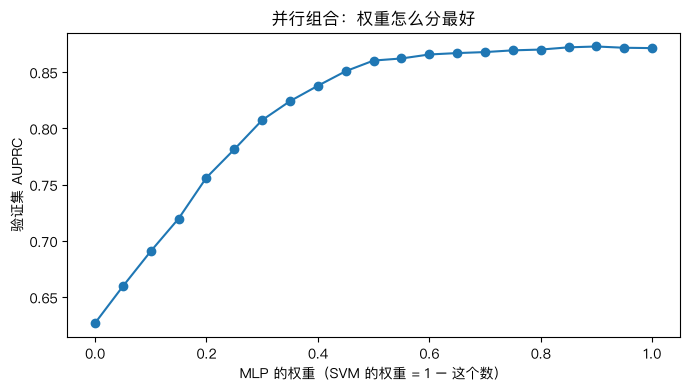

In [7]:
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LogisticRegression

start = time.time()
mlp = MLPClassifier(hidden_layer_sizes=(64, 32), activation='relu', max_iter=20, random_state=42).fit(X_fit, y_fit)
mlp_time = time.time() - start

def logit(p):
    p = np.clip(p, 1e-6, 1 - 1e-6)
    return np.log(p / (1 - p))

raw = {
    '随机森林（默认）': lambda X: logit(rf_default.predict_proba(X)[:, 1]),
    '随机森林（调参后）': lambda X: logit(rf_tuned.predict_proba(X)[:, 1]),
    'SVM（默认）': lambda X: svm_models[(1, 'scale')].decision_function(X),
    'SVM（调参后）': lambda X: svm_tuned.decision_function(X),
    'XGBoost': lambda X: logit(xgb.predict_proba(X)[:, 1]),
    'MLP': lambda X: logit(mlp.predict_proba(X)[:, 1]),
}
val_raw = {k: f(X_val) for k, f in raw.items()}
test_raw = {k: f(X_test) for k, f in raw.items()}
calib = {k: LogisticRegression().fit(v.reshape(-1, 1), y_val) for k, v in val_raw.items()}
val_prob = {k: calib[k].predict_proba(v.reshape(-1, 1))[:, 1] for k, v in val_raw.items()}
test_prob = {k: calib[k].predict_proba(v.reshape(-1, 1))[:, 1] for k, v in test_raw.items()}

weights = np.round(np.arange(0, 1.0001, 0.05), 2)
val_ap = [average_precision_score(y_val, w * val_prob['MLP'] + (1 - w) * val_prob['SVM（调参后）'])
          for w in weights]
W_MLP = weights[int(np.argmax(val_ap))]
name_par = '并行 B（MLP + 调参后 SVM）'
val_prob[name_par] = W_MLP * val_prob['MLP'] + (1 - W_MLP) * val_prob['SVM（调参后）']
test_prob[name_par] = W_MLP * test_prob['MLP'] + (1 - W_MLP) * test_prob['SVM（调参后）']
print(f'调参后，验证集选出的权重：MLP {W_MLP:.2f}，SVM {1 - W_MLP:.2f}')

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(weights, val_ap, marker='o')
ax.set_xlabel('MLP 的权重（SVM 的权重 = 1 − 这个数）')
ax.set_ylabel('验证集 AUPRC')
ax.set_title('并行组合：权重怎么分最好')
plt.tight_layout()
plt.show()

## 5. 汇总：调参前后 + XGBoost，在测试集上打分

阈值在验证集上按 F1 最高来选。这张表可以填进报告第五节"参数调优"，也是对第三节那张表的补充。

In [8]:
from sklearn.metrics import f1_score, precision_score, recall_score

def best_f1_threshold(y, p):
    prec, rec, thr = precision_recall_curve(y, p)
    f1 = 2 * prec[:-1] * rec[:-1] / np.clip(prec[:-1] + rec[:-1], 1e-12, None)
    return thr[np.argmax(f1)]

rows = []
for name in test_prob:
    t = best_f1_threshold(y_val, val_prob[name])
    pred = test_prob[name] >= t
    rows.append({
        '模型': name,
        '验证集 AUPRC': average_precision_score(y_val, val_prob[name]),
        '测试集 AUPRC': average_precision_score(y_test, test_prob[name]),
        'Recall': recall_score(y_test, pred),
        'Precision': precision_score(y_test, pred, zero_division=0),
        'F1': f1_score(y_test, pred),
        '抓到': int((pred & (y_test == 1)).sum()),
        '误报': int((pred & (y_test == 0)).sum()),
    })
final_table = pd.DataFrame(rows).set_index('模型').round(4)
final_table.to_csv(f'{DATA_DIR}/results_tuned.csv')
final_table

,验证集 AUPRC,测试集 AUPRC,Recall,Precision,F1,抓到,误报
模型,,,,,,,
随机森林（默认）,0.8628,0.8231,0.7655,0.9328,0.8409,111,8
随机森林（调参后）,0.8685,0.8048,0.7931,0.8984,0.8425,115,13
SVM（默认）,0.3866,0.3270,0.4552,0.4521,0.4536,66,80
SVM（调参后）,0.6270,0.5346,0.6621,0.5246,0.5854,96,87
XGBoost,0.8705,0.8211,0.7862,0.9421,0.8571,114,7
MLP,0.8714,0.7999,0.7310,0.9298,0.8185,106,8
并行 B（MLP + 调参后 SVM）,0.8728,0.7999,0.7379,0.9386,0.8263,107,7


## 6. SHAP：哪些特征对"判成欺诈"影响最大

SHAP 给每一笔交易的每一个特征算一个贡献值：正数表示这个特征把这笔交易往"欺诈"推，负数表示往"正常"推。把很多笔交易的贡献值汇总，就知道整体上谁最重要。
解释的对象是 XGBoost（树模型可以算得又快又准）。样本用测试集里全部欺诈 + 2000 笔随机正常交易。

**左图（条形图）**：纵轴是特征，横轴是平均贡献的大小（不分正负），越长越重要。
**右图（散点图）**：每个点是一笔交易。横轴是这个特征对这笔交易的贡献（往右 = 推向欺诈）；颜色是这个特征本身的取值（红 = 大，蓝 = 小）。比如某一行红点都在左边，意思是"这个特征越大，越不像欺诈"。

注意：V1~V28 是脱敏特征，SHAP 只能告诉你"V14 很重要"，说不出 V14 代表什么业务含义。

In [9]:
import shap

fraud_idx = np.flatnonzero(y_test == 1)
normal_idx = np.random.default_rng(0).choice(np.flatnonzero(y_test == 0), 2000, replace=False)
X_explain = pd.DataFrame(X_test[np.concatenate([fraud_idx, normal_idx])], columns=feature_cols)

explainer = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(X_explain)

importance = pd.Series(np.abs(shap_values).mean(axis=0), index=feature_cols).sort_values(ascending=False)
importance.to_csv(f'{DATA_DIR}/shap_importance.csv', header=['平均|SHAP|'])
print('平均贡献最大的 10 个特征：')
print(importance.head(10).round(4))

平均贡献最大的 10 个特征：
V4        1.0794
V10       1.0072
V14       0.9510
V12       0.7410
V15       0.3001
V8        0.2608
V3        0.2505
Amount    0.2497
V16       0.2311
V19       0.1961
dtype: float32


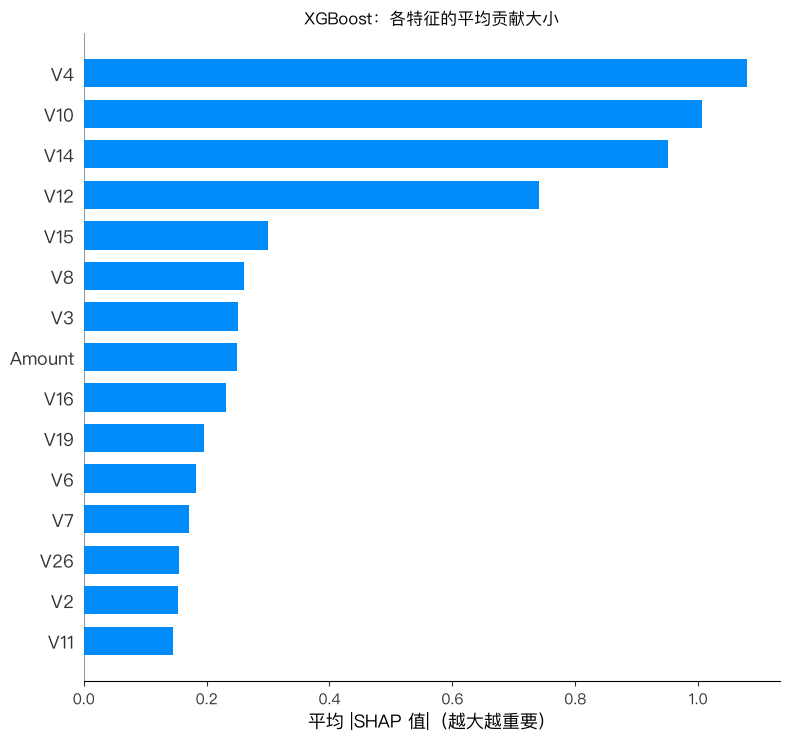

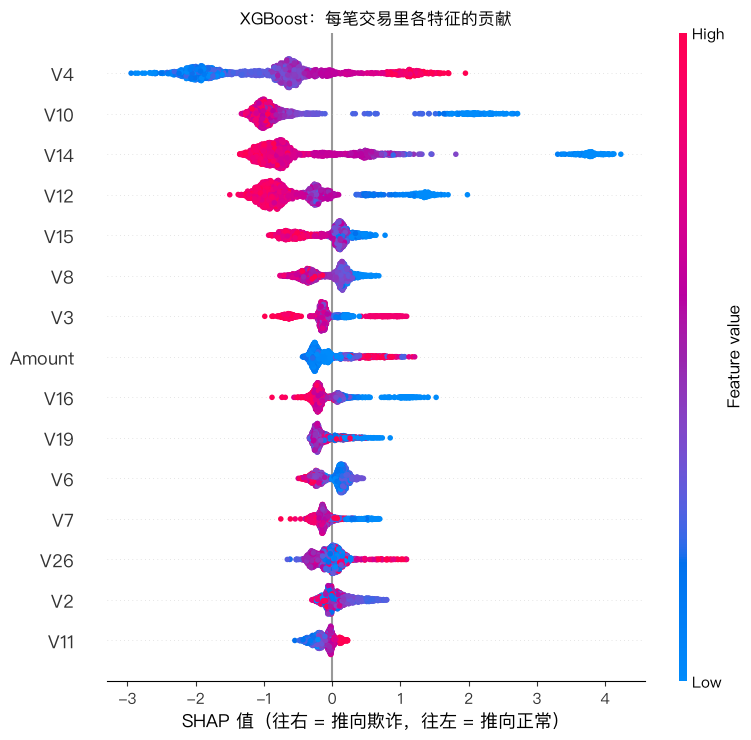

In [10]:
plt.figure()
shap.summary_plot(shap_values, X_explain, plot_type='bar', max_display=15, show=False)
plt.title('XGBoost：各特征的平均贡献大小')
plt.xlabel('平均 |SHAP 值|（越大越重要）')
plt.tight_layout()
plt.show()

plt.figure()
shap.summary_plot(shap_values, X_explain, max_display=15, show=False)
plt.title('XGBoost：每笔交易里各特征的贡献')
plt.xlabel('SHAP 值（往右 = 推向欺诈，往左 = 推向正常）')
plt.tight_layout()
plt.show()

## 7. 风险分级

用验证集 AUPRC 最高的模型，把它校准后的欺诈概率按报告模板的规则分三档：低风险 < 0.2，中风险 0.2~0.5，高风险 > 0.5。
统计每一档有多少笔交易、其中多少笔是真欺诈、涉及多少金额。"应对措施"一栏是业务建议，需要你自己写。

In [11]:
final_name = max(test_prob, key=lambda k: average_precision_score(y_val, val_prob[k]))
p = test_prob[final_name]
print('用于风险分级的模型：', final_name)

tiers = [('低风险', '概率 < 0.2', p < 0.2),
         ('中风险', '0.2 ≤ 概率 ≤ 0.5', (p >= 0.2) & (p <= 0.5)),
         ('高风险', '概率 > 0.5', p > 0.5)]
risk = pd.DataFrame([{
    '风险等级': name,
    '概率区间': rng_text,
    '交易笔数': int(m.sum()),
    '占比': m.mean(),
    '其中欺诈笔数': int((m & (y_test == 1)).sum()),
    '本档欺诈率': (y_test[m] == 1).mean() if m.any() else float('nan'),
    '本档欺诈金额': test_amount[m & (y_test == 1)].sum(),
} for name, rng_text, m in tiers]).set_index('风险等级')
risk.to_csv(f'{DATA_DIR}/risk_tiers.csv')
risk.round(4)

用于风险分级的模型： 并行 B（MLP + 调参后 SVM）


,概率区间,交易笔数,占比,其中欺诈笔数,本档欺诈率,本档欺诈金额
风险等级,,,,,,
低风险,概率 < 0.2,85289,0.9985,34,0.0004,7325.13
中风险,0.2 ≤ 概率 ≤ 0.5,25,0.0003,15,0.6000,1765.51
高风险,概率 > 0.5,102,0.0012,96,0.9412,11163.06


## 看完之后记下来（用你自己的话）

1. SVM 调参前后，验证集 AUPRC 涨了多少？最优的 C 和 gamma 是多少？
2. 随机森林调参有没有用？哪组参数最好？
3. XGBoost 和 MLP 谁更强？差距大不大？
4. SVM 调参后，并行组合给它的权重还是 0 吗？05 的结论要不要改？
5. SHAP 排名前几的特征是哪些？和 01 里"两类差别最大"的 V17、V14、V12 一致吗？
6. 高风险那一档里，真欺诈占多少？低风险那一档里还漏了几笔欺诈？你会对每一档采取什么措施？